In [7]:
import torch
import matplotlib.pyplot as plt

In [8]:
# Select the best available device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [9]:
# Create a 2D coordinate grid using PyTorch tensors

resolution = 1000

x = torch.linspace(0, 1, resolution, device=device)
y = torch.linspace(0, 1, resolution, device=device)

Y, X = torch.meshgrid(y, x, indexing="ij")

print("Grid shape:", X.shape)

Grid shape: torch.Size([1000, 1000])


In [10]:
# Scale the grid to form an equilateral triangle

sqrt3 = torch.sqrt(torch.tensor(3.0, device=device))

# A point is inside the main triangle if it satisfies these conditions
inside_triangle = (
    Y <= sqrt3 * X
) & (
    Y <= sqrt3 * (1 - X)
)

In [11]:
# Apply the Sierpiński Triangle rule using PyTorch tensors

depth = 6

# Coordinates of an equilateral triangle
sqrt3 = torch.sqrt(torch.tensor(3.0, device=device))

# Convert each grid point into barycentric-style coordinates
alpha = 1 - X - Y / sqrt3
beta = X - Y / sqrt3
gamma = 2 * Y / sqrt3

# A point starts inside the main triangle if all three coordinates are non-negative
fractal = (alpha >= 0) & (beta >= 0) & (gamma >= 0)

# Repeatedly determine which of the three corner triangles contains each point
for _ in range(depth):

    in_alpha = alpha >= 0.5
    in_beta = beta >= 0.5
    in_gamma = gamma >= 0.5

    # Points not belonging to one of the three corner triangles are removed
    keep = in_alpha | in_beta | in_gamma

    fractal &= keep

    # Rescale coordinates for the next level
    alpha = torch.where(
        in_alpha,
        2 * alpha - 1,
        2 * alpha
    )

    beta = torch.where(
        in_beta,
        2 * beta - 1,
        2 * beta
    )

    gamma = torch.where(
        in_gamma,
        2 * gamma - 1,
        2 * gamma
    )

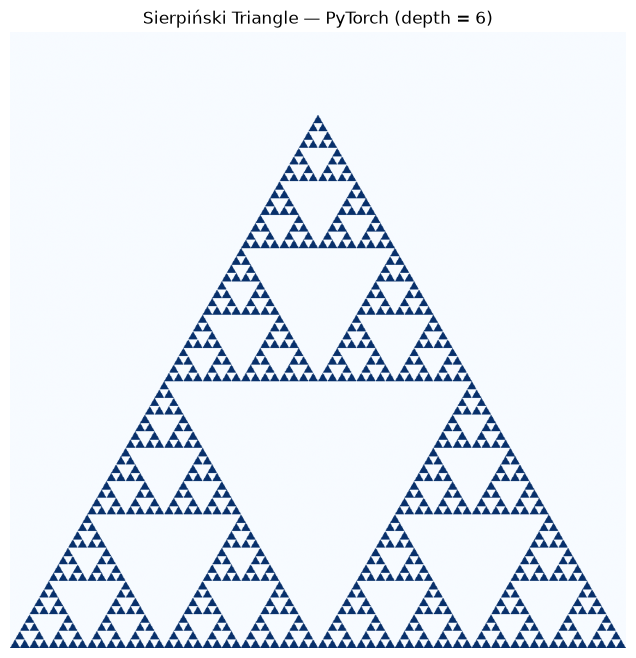

In [12]:
# Move the result to the CPU for plotting

fractal_cpu = fractal.cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(
    fractal_cpu,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="Blues"
)

plt.title(f"Sierpiński Triangle — PyTorch (depth = {depth})")
plt.axis("off")
plt.show()